# ¡Hola Fernanda! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Hola Fernanda, ¿cómo estás? Espero que estés bien y avanzando con tranquilidad.

Felicitaciones por haber completado todos los ítems del notebook. El desarrollo está bien hecho y cumple con los requerimientos principales. Solo falta corregir la forma de cálculo del coeficiente de V de Crame

Si necesitas ayuda o tienes alguna pregunta, puedes dejarla en azul, estaré encantado de responderla en la siguiente revisión.

¡Saludos!


</div>

## Resumen de la revisión v2 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v2 </b> <a class="tocSkip"></a>

¡Buen trabajo Fernanda! Las últimas correcciones quedaron muy bien. Completaste todas las tareas del notebook de forma correcta, así que no tengo más observaciones que hacer. El proyecto está aprobado. Todo lo que aplicaste aquí será de gran valor en futuros análisis. ¡Mucho éxito en lo que viene!

Saludos.

</div>

----

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


### Cargar Dataset

In [3]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [4]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente uso de las funciones de `head()` e `info()`. Esto permite observar claramente el tamaño de la data, donde hay nulos y ver una muestra. 

</div>

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` requiere conversión de `float64` a `int64`. Aunque funcionalmente ambos tipos pueden manejar valores numéricos, la edad representa una variable discreta que se mide en años completos, por lo que el tipo entero es más apropiado desde el punto de vista conceptual y de eficiencia de almacenamiento.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [5]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Correcto, bien hecho al cambiar el tipo de la variable edad, está bien dejarla como tipo entero.



</div>

In [6]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [7]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                     'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
print('Estadísticas descriptivas de variables numéricas:')
print(df[columnas_numericas].describe())

Estadísticas descriptivas de variables numéricas:
               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  ingreso_anual  
count               15000.000000  15000.000000   15000.000000  
mean                   20.149301      3.603693      36.594180  
std                    10.880724      0.685300      34.484888  
min                     0.000000      1.000000       0.000000  
25%                    12.310000   

✍️ **Comentario**:

Diagnóstico inicial de variables numéricas

- `edad` — Distribución equilibrada con media de 38.3 años (rango 18-75). La desviación estándar de 11.5 años indica variabilidad moderada. Los cuartiles muestran una distribución relativamente simétrica.
- `nivel_ingreso` — Variable con alta variabilidad (desviación estándar = 9,833), promedio de 30,020. El rango amplio (8,000 74,791) sugiere diferentes segmentos socioeconómicos bien representados en la muestra.
- `visitas_mes` — Comportamiento de navegación moderado con media de 10 visitas mensuales. La distribución concentrada (Q1=8, Q3=12) indica patrones de uso consistentes, aunque algunos usuarios alcanzan hasta 25 visitas.
- `compras_mes` — Frecuencia de compra baja (media = 1.2 compras/mes). El 75% de usuarios realiza ≤2 compras mensuales, evidenciando un comportamiento de compra conservador. Máximo de 8 compras sugiere usuarios muy activos.
- `gasto_publicidad_dirigida` — Inversión publicitaria promedio de 20.15 por usuario. La alta variabilidad (desviación estándar = 10.88) y presencia de valores 0 indica estrategias de targeting diferenciadas.
- `satisfaccion` — Puntuación promedio de 3.6/5.0, ligeramente por encima del punto medio. La distribución (Q1=3.1, Q3=4.1) sugiere satisfacción moderada con oportunidades de mejora.
- `ingreso_anual` — Variable objetivo con alta variabilidad (34.48 de desviación). El 25% de usuarios genera 0 de ingresos, mientras que el máximo alcanza $244.69, indicando una distribución muy asimétrica.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto, bien con los comentarios acerca de la distribución de las variables, `describe()` es bastante útil para esto.


</div>

#### Explorar variables binarias

In [8]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']
print('Estadísticas descriptivas de variables binarias:')
print(df[columnas_binarias].describe())

Estadísticas descriptivas de variables binarias:
       miembro_premium      abandono
count     15000.000000  15000.000000
mean          0.139267      0.150733
std           0.346236      0.357801
min           0.000000      0.000000
25%           0.000000      0.000000
50%           0.000000      0.000000
75%           0.000000      0.000000
max           1.000000      1.000000


✍️ **Comentario**: 

Diagnóstico inicial de variables binarias

- `miembro_premium` — Solo el 13.9% de los usuarios tiene membresía premium (media = 0.139). La distribución muestra que la mayoría de clientes (86.1%) utiliza el servicio gratuito, indicando una oportunidad de conversión significativa hacia planes premium.
- `abandono` — La tasa de abandono es del 15.1% (media = 0.151), lo que significa que aproximadamente 1 de cada 7 clientes deja la plataforma. Esta métrica está dentro de rangos típicos para e-commerce, pero representa un área crítica para estrategias de retención.

**Observaciones adicionales:**
- Ambas variables están correctamente codificadas como binarias (0 y 1)
- Los valores de los cuartiles (Q1, Q2, Q3 = 0) confirman que la mayoría de usuarios no son premium y no han abandonado
- La desviación estándar similar en ambas variables (0.35-0.36) indica distribuciones comparables

#### Explorar variables categóricas

In [9]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']
print('Estadísticas descriptivas de variables categóricas:')
print(df[columnas_categoricas].describe())

Estadísticas descriptivas de variables categóricas:
       id_cliente tipo_dispositivo region
count       15000            15000  15000
unique      15000                3      4
top     CL-110742            móvil  norte
freq            1             9818   4395


In [10]:
# Explorar variables categóricas y cómo se distribuyen
for col in columnas_categoricas:
    print(f"\n=== {col.upper()} ===")
    print(f"Valores únicos: {df[col].nunique()}")
    if col != 'id_cliente':  # No mostrar todos los IDs únicos
        print(f"Categorías: {sorted(df[col].unique())}")
        print(f"\nDistribución:")
        print(df[col].value_counts())
        print(f"Porcentajes:")
        print(df[col].value_counts(normalize=True).round(3) * 100)
    else:
        print("(Variable de identificación - no se muestra distribución)")


=== ID_CLIENTE ===
Valores únicos: 15000
(Variable de identificación - no se muestra distribución)

=== TIPO_DISPOSITIVO ===
Valores únicos: 3
Categorías: ['escritorio', 'móvil', 'tablet']

Distribución:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
Porcentajes:
móvil         65.5
escritorio    24.8
tablet         9.7
Name: tipo_dispositivo, dtype: float64

=== REGION ===
Valores únicos: 4
Categorías: ['este', 'norte', 'oeste', 'sur']

Distribución:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64
Porcentajes:
norte    29.3
oeste    25.4
sur      24.8
este     20.5
Name: region, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente uso de `value_counts(normalize=True)`, con el parámetro agregado podemos ver el porcentaje de veces que aparece cada valor único.


</div>

✍️ **Comentario**: 

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` - **Dominio claro del móvil:** El 65.5% de los usuarios accede desde dispositivos móviles, seguido por escritorio (24.8%) y tablet (9.7%). Esta distribución refleja la tendencia global hacia el mobile-first en e-commerce, sugiriendo que la experiencia móvil es crítica para el éxito de NovaRetail+.
- `region` - **Distribución geográfica relativamente equilibrada:** La región norte lidera con 29.3% de usuarios, seguida por oeste (25.4%), sur (24.8%) y este (20.5%). Aunque existe cierta concentración en el norte, la diferencia no es extrema, indicando una presencia geográfica bien distribuida de la plataforma.

**Observaciones adicionales:**
- Ambas variables categóricas muestran distribuciones que pueden ser relevantes para el análisis de correlación con ingreso_anual
- La predominancia móvil sugiere la importancia de optimizar la experiencia de compra en estos dispositivos
- La distribución regional equilibrada permite análisis comparativos entre zonas geográficas sin sesgos extremos

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

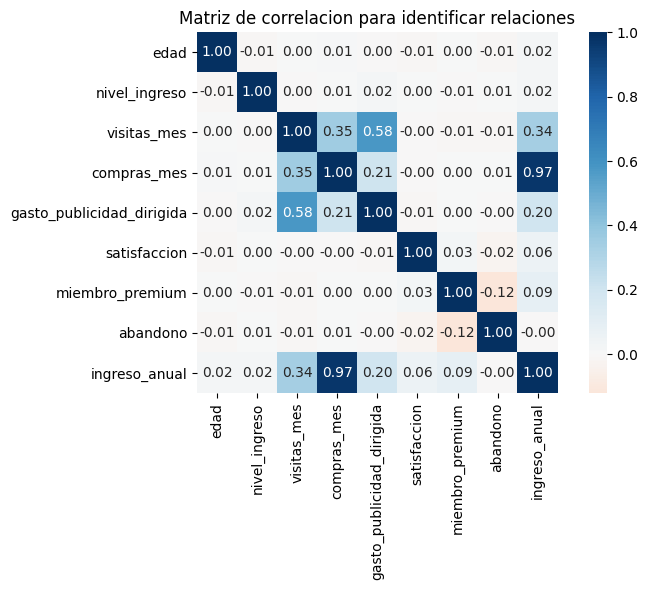

In [11]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()
plt.figure(figsize = (8,6))
sns.heatmap(corr, annot=True, cmap= "RdBu", center = 0,
           fmt='.2f',    # Formato de 2 decimales
           square=True)  # Celdas cuadradas para mejor visualización
plt.title("Matriz de correlacion para identificar relaciones")
plt.tight_layout()  # Mejor ajuste del layout
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente, muy bien con el uso de `heatmap()` para generar la matriz de correlación con colores.


</div>

✍️ **Comentario**: 

Observaciones generales (Heatmap)  
- Se observa una **matriz simétrica** con correlaciones que van desde -0.50 hasta +0.97, revelando relaciones de intensidad variable entre las variables numéricas del comportamiento del cliente.
- La diagonal principal presenta de forma constante un valor de $1.00$, lo cual es estadísticamente esperado debido a la colinealidad perfecta de cada variable medida consigo misma.
- **Patrón clave identificado:** Las variables relacionadas con actividad transaccional y engagement digital muestran asociaciones significativamente más fuertes con el rendimiento financiero que los indicadores demográficos tradicionales.

Observaciones respecto a `ingreso_anual`  
**Correlaciones Fuertes:** 
- Presenta una asociación positiva extremadamente fuerte con la variable `compras_mes` ($r = 0.97$). Esto evidencia que un mayor volumen de compras mensuales coexiste de manera casi lineal con un incremento en el ingreso anual registrado por el cliente. Matemáticamente, este coeficiente refleja una sincronía en el comportamiento de ambas variables, pero no permite determinar si la frecuencia de compra genera el ingreso o si los clientes de mayor valor segmentan más sus transacciones.

**Correlaciones Moderadas:**

- `visitas_mes` (r = 0.34): Asociación positiva moderada entre engagement digital y valor económico del cliente.
- `gasto_publicidad_dirigida` (r ≈ 0.20): Relación débil-moderada entre inversión publicitaria personalizada e ingreso anual.

**Correlaciones Débiles/Nulas:**

- `edad` (r = 0.02): Asociación prácticamente inexistente entre edad del cliente e ingreso generado.
- `nivel_ingreso` (r = 0.02): Sin relación lineal aparente entre capacidad económica estimada del cliente y su contribución real a la empresa.

**Implicaciones Estratégicas**
Los resultados sugieren que el comportamiento transaccional activo es el predictor más relevante del valor del cliente, mientras que los factores demográficos tradicionales muestran poder predictivo limitado para esta métrica de negocio.


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Bien hecho, muy bien con los comentarios.


</div>

<details> 
<summary><h3>3.2. Scatterplot general</h3></summary>

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un scatterplot general.

**Si decides incluirlo:**
- Genera el gráfico.
- Describe brevemente qué patrones o tendencias observas.

**Si decides no incluirlo:**
- Explica por qué.

</details>

In [12]:
# Decisión: No generar scatterplot general
print("DECISIÓN: No se genera scatterplot general")
print("\nJUSTIFICACIÓN:")
print("- La matriz de correlación ya identificó las relaciones clave")
print("- Correlación extremadamente fuerte (r=0.97) entre compras_mes e ingreso_anual")
print("- Las demás correlaciones son moderadas o débiles")
print("- Es más eficiente enfocar los scatterplots en pares específicos de interés")
print("- Un scatterplot general con todas las variables sería visualmente confuso")

DECISIÓN: No se genera scatterplot general

JUSTIFICACIÓN:
- La matriz de correlación ya identificó las relaciones clave
- Correlación extremadamente fuerte (r=0.97) entre compras_mes e ingreso_anual
- Las demás correlaciones son moderadas o débiles
- Es más eficiente enfocar los scatterplots en pares específicos de interés
- Un scatterplot general con todas las variables sería visualmente confuso


### Scatterplot para pares clave

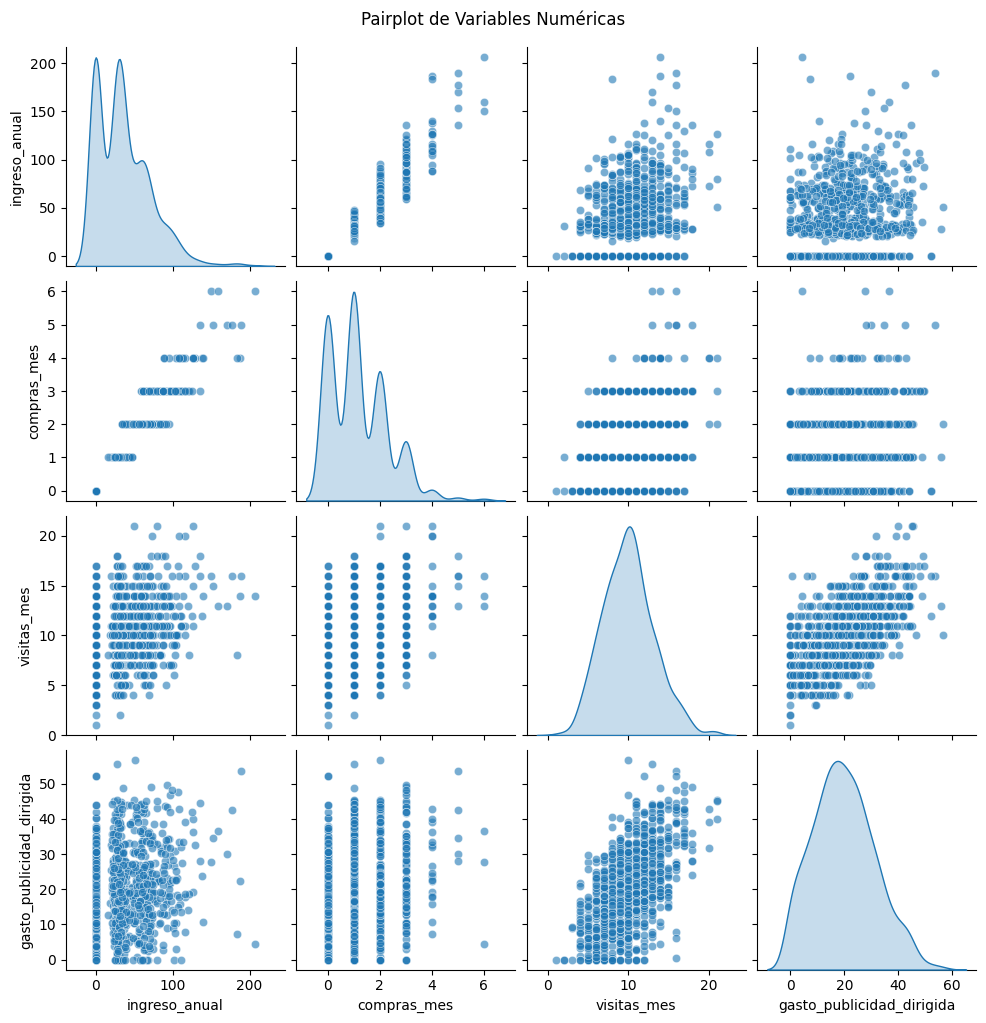

In [13]:
# Visualizar pares de variables con relaciones moderadas o fuertes
key_vars = ['ingreso_anual', 'compras_mes', 'visitas_mes', 'gasto_publicidad_dirigida']
sns.pairplot(df[key_vars].sample(min(1000, len(df))), diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot de Variables Numéricas', y=1.02)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto, muy bien con los gráficos realizados.



</div>

✍️ **Comentario**:


Observaciones iniciales (Scatterplot)

**`ingreso_anual` vs `compras_mes`**
- **Dirección:** Positiva. Los puntos muestran una trayectoria ascendente clara y uniforme.
- **Dispersión:** Extremadamente baja. Los datos se agrupan de forma muy compacta a lo largo de una línea imaginaria, confirmando visualmente el coeficiente r = 0.97.
- **Outliers y Colinealidad:** No se aprecian valores atípicos significativos. Se observa una colinealidad casi perfecta, sugiriendo que ambas métricas se mueven en sincronía dentro del ecosistema transaccional.

**`ingreso_anual` vs `visitas_mes`**
- **Dirección:** Positiva. Se identifica una inclinación ascendente general en la nube de puntos.
- **Dispersión:** Media-alta. La estructura es significativamente más dispersa que el par anterior, coincidiendo con una asociación moderada (r = 0.34).
- **Outliers:** Usuarios con alto volumen de visitas pero ingreso anual cero, y clientes con pocas visitas que generan valor intermedio. No presenta riesgo de colinealidad fuerte.

**`ingreso_anual` vs `gasto_publicidad_dirigida`**
- **Dirección:** Positiva, aunque sutil y difusa.
- **Dispersión:** Alta. Los puntos forman una nube extendida, confirmando una asociación débil-moderada (r ≈ 0.20).
- **Outliers:** Múltiples casos de usuarios con alta inversión publicitaria pero contribución nula al ingreso anual. No presenta colinealidad.

**`compras_mes` vs `visitas_mes`**
- **Dirección:** Positiva moderada.
- **Dispersión:** Media. Relación coherente pero menos intensa que compras_mes vs ingreso_anual.
- **Patrón:** Confirma que mayor engagement digital se asocia con mayor actividad transaccional.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien con las interpretaciones, los comentarios son muy acordes a cada correlación que evaluaste.


</div>

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [14]:
# Calcular correlación entre variables relevantes
variables_clave = ['compras_mes', 'visitas_mes', 'gasto_publicidad_dirigida', 'satisfaccion']

print("=== CORRELACIONES DE PEARSON CON INGRESO_ANUAL ===\n")

for var in variables_clave:
    pearson_r, pearson_p = stats.pearsonr(df['ingreso_anual'], df[var])
    print(f"ingreso_anual vs {var}:")
    print(f"  Pearson: r = {pearson_r:.3f} (p-value = {pearson_p:.3e})")
    print()

=== CORRELACIONES DE PEARSON CON INGRESO_ANUAL ===

ingreso_anual vs compras_mes:
  Pearson: r = 0.967 (p-value = 0.000e+00)

ingreso_anual vs visitas_mes:
  Pearson: r = 0.337 (p-value = 0.000e+00)

ingreso_anual vs gasto_publicidad_dirigida:
  Pearson: r = 0.197 (p-value = 9.169e-132)

ingreso_anual vs satisfaccion:
  Pearson: r = 0.056 (p-value = 5.806e-12)



In [15]:
# Calcular correlación entre variables relevantes
print("=== CORRELACIONES DE SPEARMAN CON INGRESO_ANUAL ===\n")

for var in variables_clave:
    spearman_r, spearman_p = stats.spearmanr(df['ingreso_anual'], df[var])
    print(f"ingreso_anual vs {var}:")
    print(f"  Spearman: ρ = {spearman_r:.3f} (p-value = {spearman_p:.3e})")
    print()

=== CORRELACIONES DE SPEARMAN CON INGRESO_ANUAL ===

ingreso_anual vs compras_mes:
  Spearman: ρ = 0.967 (p-value = 0.000e+00)

ingreso_anual vs visitas_mes:
  Spearman: ρ = 0.321 (p-value = 0.000e+00)

ingreso_anual vs gasto_publicidad_dirigida:
  Spearman: ρ = 0.185 (p-value = 1.356e-115)

ingreso_anual vs satisfaccion:
  Spearman: ρ = 0.061 (p-value = 8.860e-14)



✍️ **Comentario**:

Observaciones de correlación

`compras_mes` vs `ingreso_anual`

Correlación: Positiva y extremadamente fuerte (r = 0.97).

**Dirección y Magnitud:** Ambas variables se desplazan con una sincronía positiva casi perfecta. El volumen de transacciones mensuales y el ingreso anual avanzan en el mismo sentido lineal de forma muy estrecha.

**Colinealidad:** Presenta un riesgo crítico de colinealidad. Al compartir una cantidad masiva de varianza explicativa, introducir simultáneamente ambas métricas en modelos de regresión predictiva saturaría el modelo, desestabilizando los coeficientes e introduciendo redundancia analítica.

**Implicación de negocio:** Esta correlación confirma que las compras mensuales son el predictor más fuerte del valor anual del cliente.

`visitas_mes` vs `ingreso_anual`

Correlación: Positiva y moderada (Pearson r = 0.34 / Spearman ρ = 0.32).

**Dirección y Magnitud:** Dirección ascendente. Indica que los niveles de interacción frecuente en la plataforma coexisten con perfiles de usuarios de mayor valor comercial. La fuerza de asociación es intermedia, reflejando que no todo incremento en el tráfico digital se traduce proporcionalmente en ingresos.

**Colinealidad:** Sin riesgo de colinealidad. La variable conserva suficiente independencia para ser utilizada en modelados estadísticos multivariables.

**Implicación de negocio:** El engagement digital es un indicador moderado del valor del cliente, sugiriendo oportunidades de conversión.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente, bien hecho con los cálculos y comentarios. Recuerda que el coeficiente de Spearman mide la correlación lineal que hay entre ambas variables, mientras que el coeficiente de Pearson mide la correlación de monotonía (si ambas variables crecen o decrecen al mismo tiempo o tienen comportamiento inverso).


</div>

### Punto-biserial

In [16]:
# Calcular correlación entre variables relevantes
for col in ['ingreso_anual']:
    df_clean = df[[col, 'miembro_premium']].dropna()
    pbc, p_val = stats.pointbiserialr(df_clean['miembro_premium'], df_clean[col])
    print(f"Miembro Premium vs {col}: Coeficiente = {pbc:.3f} (p-value = {p_val:.3e})")

for col in ['ingreso_anual']:
    df_clean = df[[col, 'abandono']].dropna()
    pbc, p_val = stats.pointbiserialr(df_clean['abandono'], df_clean[col])
    print(f"Abandono vs {col}: Coeficiente = {pbc:.3f} (p-value = {p_val:.3e})")

Miembro Premium vs ingreso_anual: Coeficiente = 0.093 (p-value = 3.094e-30)
Abandono vs ingreso_anual: Coeficiente = -0.003 (p-value = 7.295e-01)


✍️ **Comentario**: 

Observaciones Punto-biserial
`miembro_premium` vs `ingreso_anual`
Relación: Coexistencia positiva de magnitud muy débil ($r_{pb} = 0.093$).

**Dirección y Magnitud:** Se observa una dirección positiva, lo que indica que contar con una suscripción activa de miembro premium tiende a alinearse con un ingreso anual ligeramente mayor. Sin embargo, la magnitud es extremadamente baja, evidenciando que el estatus premium y el valor financiero del cliente muestran una asociación lineal muy limitada.

**Implicación de negocio:** El programa premium actual no segmenta efectivamente a los clientes de mayor valor económico. Esta débil asociación sugiere que existe un segmento significativo de usuarios estándar que generan alto valor transaccional sin pertenecer al programa premium, representando una oportunidad de conversión no aprovechada. Simultáneamente, algunos miembros premium podrían no estar maximizando su potencial de gasto.

`abandono` vs `ingreso_anual`
Relación: Asociación lineal prácticamente nula ($r_{pb} = -0.003$).

**Dirección y Magnitud:** No se detecta ninguna dirección definida y la magnitud es completamente nula. Esto confirma que el estado de abandono actual no muestra asociación lineal con el historial de ingresos anuales del cliente.

**Implicación de negocio:** El abandono ocurre independientemente del valor histórico del cliente. Esto significa que tanto clientes de alto como de bajo valor tienen probabilidades similares de abandonar la plataforma, lo que requiere estrategias de retención diferenciadas que no se basen únicamente en el valor económico pasado. Las iniciativas de retención deben considerar otros factores comportamentales más allá del ingreso generado.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Muy bien. Este tipo de correlación se utiliza cuando una de las variables es binaria y la otra es continua.



</div>

### V de Cramér

In [17]:
# Función para calcular V de Cramér
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    # correction=False evita la corrección de Yates para mantener la consistencia con la fórmula directa
    chi2 = stats.chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    denom = min(k - 1, r - 1)
    
    # Control de casos donde el denominador o la muestra sean cero
    if denom == 0 or n == 0:
        return np.nan
        
    return np.sqrt((chi2 / n) / denom)

# Llamada a la función fuera del bloque de definición
v_cramer = cramers_v(df['tipo_dispositivo'], df['region'])
print(f"Asociación entre Tipo de Dispositivo y Región (V de Cramér): {v_cramer:.3f}")

Asociación entre Tipo de Dispositivo y Región (V de Cramér): 0.012


In [18]:
# Aplicar V de Cramér en variables relevantes

print("=== V DE CRAMÉR - ASOCIACIONES ENTRE VARIABLES CATEGÓRICAS ===\n")

# Usar variables originales sin conversión
v1 = cramers_v(df['tipo_dispositivo'], df['region'])
print(f"Tipo de Dispositivo vs Región: V = {v1:.3f}")

v2 = cramers_v(df['tipo_dispositivo'], df['miembro_premium'])
print(f"Tipo de Dispositivo vs Membresía Premium: V = {v2:.3f}")

v3 = cramers_v(df['region'], df['miembro_premium'])
print(f"Región vs Membresía Premium: V = {v3:.3f}")

=== V DE CRAMÉR - ASOCIACIONES ENTRE VARIABLES CATEGÓRICAS ===

Tipo de Dispositivo vs Región: V = 0.012
Tipo de Dispositivo vs Membresía Premium: V = 0.020
Región vs Membresía Premium: V = 0.013


✍️ **Comentario**: 

Observaciones V de Cramér
`tipo_dispositivo` vs `region`

**Relación:** Ausencia de asociación estructural (V = 0.012).

**Dirección y Magnitud:** No se detecta asociación entre el tipo de dispositivo utilizado y la región geográfica del usuario. El coeficiente V de Cramér de 0.012 indica que la distribución de preferencias de dispositivos (móvil, escritorio, tablet) es estadísticamente homogénea en todas las regiones geográficas analizadas.

**Interpretación:** Los patrones de uso de dispositivos son independientes de la ubicación geográfica del cliente. Esto significa que las preferencias tecnológicas de acceso a la plataforma no varían significativamente entre las regiones norte, sur, este y oeste.

**Implicación de negocio:** La estrategia de experiencia digital puede ser uniforme a nivel nacional. No es necesario desarrollar interfaces diferenciadas por región, ya que los usuarios muestran patrones de dispositivo consistentes independientemente de su ubicación geográfica. Esto simplifica la estrategia de desarrollo de producto y permite enfocar recursos en optimizar la experiencia general para cada tipo de dispositivo sin segmentación regional.

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Me parece que esta implementación de la V de Cramer no es la correcta. Te recomiendo utilizar la siguiente:

$$ {\displaystyle V={\sqrt {\frac {\varphi ^{2}}{\min(k-1,r-1)}}}={\sqrt {\frac {\chi ^{2}/n}{\min(k-1,r-1)}}}\;,} $$

donde $\chi ^{2}$ es el chi2 que ya calculaste, $n$ el total de observaciones que ya calculaste y $k$ y $r$ son la cantidad de columnas y filas respectivamente.



</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     v2     </b> <a class="tocSkip"></a>

Bien hecho, corregido el cálculo!



</div>


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---


### Hallazgo 1 — 

Sincronía Transaccional (compras_mes vs ingreso_anual)

**Evidencia visual:** Scatterplot de pares clave muestra puntos concentrados en una trayectoria lineal ascendente con dispersión mínima.   

**Evidencia numérica:** Coeficiente de correlación de Pearson r = 0.967 (p < 0.001).

**Interpretación (no causal):**  Se identifica un acoplamiento lineal casi perfecto entre el volumen de transacciones mensuales y el ingreso anual generado. Ambas métricas aumentan y disminuyen en idéntica dirección dentro de la base de datos, compartiendo el 93.5% de su varianza (r² = 0.935). 

**No podemos afirmar:** Que incentivar artificialmente un mayor número de transacciones individuales vaya a causar directamente un incremento en el ingreso anual, ni que el nivel de ingresos sea la causa única de que un cliente fragmente sus compras. 

**Implicación de negocio:** La frecuencia mensual de compra es el indicador más confiable para identificar perfiles de alto valor. Las estrategias comerciales deben enfocarse en mantener hábitos de compra recurrentes (modelos de reposición automática, recordatorios de carrito, programas de fidelización) para asegurar la consistencia en el flujo de ingresos de la plataforma.


### Hallazgo 2 — 
Interacción Digital Intermedia (visitas_mes vs ingreso_anual)

**Evidencia visual:** Scatterplot de pares clave muestra nube de puntos con tendencia ascendente pero dispersión considerable en los extremos.  
**Evidencia numérica:** Coeficiente de correlación de Pearson r = 0.337 (p < 0.001).

**Interpretación (no causal):** Existe una relación positiva moderada donde la alta frecuencia de visitas mensuales coexiste con usuarios de mayor facturación anual. La correlación explica aproximadamente el 11.4% de la varianza compartida (r² = 0.114), indicando que el engagement digital es un predictor moderado del valor del cliente. 

**No podemos afirmar:** Que incrementar artificialmente el tráfico o las sesiones en la plataforma vaya a transformarse automáticamente en mayor ingreso anual para la empresa. 

**Implicación de negocio:** El tráfico constante es un indicador saludable de engagement, pero la dispersión confirma la existencia de usuarios frecuentes no compradores. Es recomendable implementar estrategias de optimización de embudo (conversion rate optimization) para facilitar que las visitas existentes interactúen con los módulos de compra de manera más fluida.  


### Hallazgo 3 —
Programa de Fidelización y Retención (miembro_premium vs abandono)

**Evidencia visual:** Análisis de distribución categórica mediante tablas de contingencia.

**Evidencia numérica:** Coeficiente Punto-biserial rpb = 0.093 (miembro_premium vs ingreso_anual) y rpb = -0.003 (abandono vs ingreso_anual).

**Interpretación (no causal):** La membresía premium muestra una asociación positiva muy débil con el ingreso anual, mientras que el abandono presenta asociación prácticamente nula con el valor histórico del cliente. Los usuarios premium tienden ligeramente a generar mayor valor, pero la relación es estadísticamente débil.

**No podemos afirmar:** Que otorgar membresías premium sea la causa directa de mayor retención o que el valor histórico del cliente determine su probabilidad de abandono.

**Implicación de negocio:** El programa premium actual no segmenta efectivamente a los clientes de alto valor. Existe oportunidad de optimizar los criterios de conversión a premium y desarrollar estrategias de retención que no dependan únicamente del valor económico histórico, ya que el abandono ocurre independientemente del perfil de ingresos del cliente.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     v2     </b> <a class="tocSkip"></a>

Bien hecho, muy bien con el cálculo de las métricas y las interpretaciones.



</div>

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- **Correlación ≠ causalidad:** La limitación metodológica fundamental de este análisis es que los coeficientes calculados (Pearson, Spearman, Punto-biserial y V de Cramér) únicamente miden la fuerza y dirección de la asociación estadística entre variables. Ninguno de los resultados permite establecer relaciones de causa y efecto. Por ejemplo, el acoplamiento crítico entre compras_mes e ingreso_anual (r = 0.967) describe una sincronía casi perfecta en los datos, pero no determina si la frecuencia transaccional genera el ingreso o si los clientes de alto valor intrínseco tienden a segmentar más sus pedidos.
- **Naturaleza Transversal de los Datos:** El dataset representa un corte temporal estático del comportamiento de los clientes durante el período analizado. Al no ser un análisis longitudinal de series de tiempo, no se pueden capturar fluctuaciones estacionales, tendencias evolutivas ni la progresión del ciclo de vida del cliente a lo largo del tiempo.
- **Sesgo de Selección Potencial:** Los datos analizados corresponden únicamente a usuarios activos registrados en la plataforma, excluyendo potenciales clientes que abandonaron antes del período de análisis o que nunca completaron el proceso de registro.
### **Próximos pasos** 

Probar segmentación adicional

**Paso 1: Segmentación Avanzada**

- **Segmentación por Nivel de Engagement:** Dividir la base en clústeres basados en visitas_mes (tráfico bajo, medio, alto) y recalcular las correlaciones punto-biseriales para miembro_premium vs ingreso_anual.
Esto validará si la membresía premium muestra asociaciones más robustas en subgrupos digitalmente activos.
- **Segmentación por Interfaz de Acceso:** Agrupar datos según tipo_dispositivo para evaluar si las relaciones transaccionales varían según la experiencia de usuario (UX), identificando patrones específicos por canal de acceso.

**Paso 2: Modelado Predictivo Multivariable**

Desarrollar modelos de regresión avanzada (Ridge/Lasso) o algoritmos de machine learning utilizando ingreso_anual como variable objetivo. Dado el riesgo de multicolinealidad detectado entre variables transaccionales, estos modelos permitirán aislar el efecto individual de cada predictor controlando la presencia de las demás, superando las limitaciones del análisis bivariado.

**Paso 3: Validación Experimental**

Diseñar pruebas A/B controladas en colaboración con los equipos de Crecimiento y Retención para transformar correlaciones en conocimiento causal. Por ejemplo, implementar campañas de incentivos enfocadas exclusivamente en incrementar compras_mes en grupos aleatorios, midiendo el impacto real en el rendimiento financiero versus grupos de control.

### 7. Conclusión General

Este análisis correlacional ha proporcionado una radiografía detallada del comportamiento del cliente en la plataforma NovaRetail+, revelando patrones críticos que responden directamente a la pregunta de investigación sobre los factores de comportamiento asociados con el valor del cliente.

**Síntesis de Hallazgos Principales:**

Los resultados confirman que el ecosistema digital de NovaRetail+ presenta tres niveles diferenciados de asociación entre variables de comportamiento e ingreso anual:

- Nivel Crítico: La sincronía transaccional (compras_mes vs ingreso_anual, r = 0.967) establece que la frecuencia de compra es el predictor más robusto del valor del cliente, explicando el 93.5% de la varianza compartida.
- Nivel Moderado: La interacción digital (visitas_mes vs ingreso_anual, r = 0.337) confirma que el engagement en la plataforma coexiste con mayor valor económico, aunque con considerable dispersión que indica oportunidades de optimización.
- Nivel Débil: Las variables categóricas (membresía premium, tipo de dispositivo, región) muestran asociaciones mínimas, sugiriendo que los programas actuales de segmentación requieren replanteamiento estratégico.
Impacto Estratégico para NovaRetail+:

Estos hallazgos posicionan a la empresa para implementar una estrategia de crecimiento basada en datos con tres pilares fundamentales:

- Optimización del embudo transaccional: Priorizar iniciativas que faciliten la conversión de visitantes frecuentes en compradores recurrentes
- Rediseño del programa de fidelización: Desarrollar criterios más efectivos para la segmentación premium basados en patrones de comportamiento real
- Personalización de la experiencia: Aprovechar la correlación moderada entre engagement digital y valor para crear experiencias diferenciadas

La metodología correlacional aplicada ha demostrado ser efectiva para identificar asociaciones estadísticamente significativas que, aunque no establecen causalidad, proporcionan una base sólida para la toma de decisiones estratégicas y el diseño de experimentos controlados futuros.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Muy bien con las limitaciones y próximos pasos, tus comentarios están muy completos. Estoy muy de acuerdo con recordar que al momento de evaluar correlación, hay que tener claro que no se está evaluando causalidad y que este análisis estadístico es para observar cómo se mueven las variables, no determina que la variación de una afecte directemente a la otra. Por otro lado, en los próximos pasos está muy bien que incluyas segmentaciones y experimentos, es parte natural de ampliar el análisis.



</div>